# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import soundfile as sf

# Chapter 12: Analyzing IIR filters

> ...(Infinite impulse response) filters can be both more powerful and more efficient than FIR (convolutional) filters. However, these benefits come with a cost: IIR filters cannot be analyzed _directly_ by the discrete Fourier transform.

## 12.1. The z-transform

> ... can we analyze IIR filters in the frequency domain as well?
> It turns out that the answer is yes, but **not** with the discrete Fourier transform. We’ll need a new tool, which is known as the _z-transform..._

### 12.1.1. Why can’t we use the DFT?

The DFT is defined in terms of a _finite_ number of analysis frequencies: those which complete an integral number of cycles over a fixed duration of time ($N$ samples).

Consider the case of an IIR filter, such as the exponential moving average we saw earlier as

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#e41a1c}\frac{1}{2}} \cdot {\color{#377eb8}x[n]} + {\color{#4daf4a}\frac{1}{2}} \cdot {\color{#984ea3}y[n-1]} & \text{(11.1)}  \\
\end{flalign}

Its impulse response can be infinite in length: there is no finite $N$ for which all $y[n > 0] = 0$, and so we cannot even begin to construct a DFT.

### 12.1.2. Defining the z-transform

We start with the definition of the Discrete Fourier Transform for a frequency index $m$:

\begin{flalign}
\qquad X[m] &= \sum_{n=0}^{{\color{#377eb8}N-1}} x[n] \cdot e^{-j \cdot 2\pi \cdot \frac{m}{{\color{#377eb8}N}} \cdot n} & \\
\end{flalign}

Note that ${\color{#377eb8}N}$ appears in two places: a) in the limit of the summation; and b) in the denominator in the complex exponential. This is the key limitation of the DFT that prevents us from applying it in the case of IIR, so let's see about removing this limitation.

##### _Leverage the exponent multiplication rule_

Recall that with exponents, powers can be represented as multiplication and vice-versa.

\begin{flalign}
\qquad e^{a \cdot b} &= \left( e^a \right)^b & \\
\end{flalign}

So in factoring out that $-n$ in the complex exponential bit, we can rewrite that as:

\begin{flalign}
\qquad e^{-j \cdot 2\pi \cdot \frac{m}{N} \cdot n} &= \left( e^{j \cdot 2\pi \cdot \frac{m}{N}} \right)^{-n} & \\
\end{flalign}

And now we can re-interpret the complex exponential bit as a sequence, _parameterized by sample index $n$_, and _generated by a complex number $z_{m/N}$ on the unit circle at the angle $\theta = 2\pi \cdot \frac{m}{N}$._

\begin{flalign}
\qquad z_{m/N} &= e^{j \cdot 2\pi \cdot \frac{m}{N}} & \text{(12.1)} \\
\end{flalign}


* $\frac{m}{N}$ is the fraction of the unit circle we travel in each step $n$ of this sequence. In the image below, $\theta = \frac{2\pi}{8}$. The complex number $z_{1/8} = e^{j \cdot 2pi \cdot \frac{1}{8}}$ is raised to successive powers for $n = 0, -1, -2, -3, \ldots$. The result is a clockwise movement from ${z_{1/8}}^0$ going around in steps of $\frac{2\pi}{8}$ radians.

![McFee's Digital Signals Theory, Ch. 12, Figure 12.1](bin/dstbook_fig_12.1.png)


* So, we can transform the DFT summation up to a finite $N-1$ to another summation, but this one going up to infinity!

\begin{flalign}
\qquad X[m] &= \sum_{n=0}^{{\color{#377eb8}N-1}} x[n] \cdot e^{-j \cdot 2\pi \cdot \frac{m}{{\color{#377eb8}N}} \cdot n} & \\\\
\qquad      &= \sum_{n=0}^{\infty} x[n] \cdot \left( z_{m/N} \right)^{-n} & \\\\
\end{flalign}

where we <span style="background-color:#3FF;">_assume silence after ${\color{#377eb8}N}$ samples instead of just pure, infinite repetition._</span>

##### Definition 12.1 (The z-transform)

> Given a sequence ${\color{#377eb8}x[n]}$ (of possibly infinite length), the z-transform is a function $X(z)$ over complex numbers $z$ defined as follows:
>
> \begin{flalign}
\qquad X(z) &= \sum_{n=0}^{\infty} x[n] \cdot z^{-n} & \text{(12.2)} \\
\end{flalign}

### 12.1.3. Relating the z-transform to the DFT

* Unlike the DFT, the z-transform does not produce a finite sequence of coefficients.
* Instead, it produces a function that can be evaluated for any complex number $z$.
* So the DFT can be recovered from the z-transform by evaluating $X(z)$ at carefully chosen points $z$.
* The DFT coefficients $X[m]$ can be extracted from the _z-transform_ as follows:

\begin{flalign}
\qquad X[m] &= X \left( e^{j \cdot 2\pi \cdot \frac{m}{N}} \right) & \\\\
\end{flalign}

### 12.1.4. Aside: continuous frequency and the DTFT

* The _Discrete-time Fourier Transform_ (DTF) is a special case of the _z-transform._
* The DFT uses ${\color{#377eb8}N}$ analysis frequences $0, \frac{f_s}{{\color{#377eb8}N}}, \frac{2 \cdot f_s}{{\color{#377eb8}N}}, \frac{3 \cdot f_s}{{\color{#377eb8}N}}, \ldots$
* In contrast, the DTFT is defined for **any** frequency $f$, and not just only analysis frequencies.
* The DTFT for any frequency $f$ is obtained by evaluating the _z-transform_ at a point on the unit-circle with angle $\theta = \frac{2\pi \cdot f}{f_s}$:

\begin{flalign}
\qquad DTFT(x)(f) &= X \left( e^{j \cdot 2\pi \cdot \frac{f}{f_s}} \right) & \\\\
\end{flalign}

* And so the DTFT makes the connection between _frequency_ and _angle_ precisely: frequency $f$ with sampling frequency $f_s$ is mapped to a complex number with _unit magnitude_ and _angle_ $\theta = \frac{2\pi \cdot f}{f_s}$.
* <span style="background-color:#3FF;">Aliasing frequencies map to the same angle, as:</span>

\begin{flalign}
\qquad 2\pi \cdot \frac{f + {\color{#cb181d}k \cdot f_s}}{f_s} &= 2\pi \cdot \frac{f}{f_S} + 2\pi \cdot {\color{#cb181d}k} & \\\\
\qquad                                                         &= 2\pi \cdot \frac{f}{f_S}  & \\\\
\end{flalign}

* <span style="background-color:#3FF;">The Nyquist frequency $f = \frac{f_s}{2}$ is mapped to angle $2\pi \cdot \frac{f_s/2}{f_s} = \pi \equiv -\pi$</span>
* In the DTFT, the analysis frequencies of the DFT are generalized using $f = m \cdot \frac{f_s}{N}$, which recovers the $z_{m/N}$ explained earlier.
* Furthermore, the range of frequencies $0 \leq f \leq f_s$  are mapped continuously to the range of angles $0 \leq \theta \leq 2\pi$
. 

## 12.2. Properties of the _z-transform_

### 12.2.1. Linearity

##### Theorem 12.1 (The _z-Transform is linear_)

> Let $y[n] = {\color{#984ea3}c_1} \cdot {\color{#377eb8}x_1[n]}  + {\color{#984ea3}c_2} \cdot {\color{#377eb8}x_2[n]}$
> be a combination of two signals ${\color{#377eb8}x_1[n]}$ and ${\color{#377eb8}x_2[n]}$, each with gain coefficients
> ${\color{#984ea3}c_1, c_2} \in \mathbb{R}$.
> <p/>
> The <i>z-transform</i> of $y[n]$ is equivalent to:
> \begin{flalign}
\qquad Y(z) &= {\color{#984ea3}c_1} \cdot {\color{#377eb8}X_1(z)}  + {\color{#984ea3}c_2} \cdot {\color{#377eb8}X_2(z)}  & \\
\end{flalign}
> where ${\color{#377eb8}X_1(z), X_2(z)}$ are the <i>z-transforms</i> of ${\color{#377eb8}x_1[n]}$ and ${\color{#377eb8}x_2[n]}$ respectively.


##### _i.e., the z-Transform of a weighted combination of signals is equivalent to the weighted combination of their individual z-Transforms._


### 12.2.2. Shifting theorem

##### Theorem 12.2 (_z-Transform shifting theorem_)

> Let $y[n] = {\color{#377eb8}x[n -} {\color{#e41a1c}k}{\color{#377eb8}]}$ be a ${\color{#e41a1c}k}$-step delay of signal ${\color{#377eb8}x[n]}$,
> under the assumption that ${\color{#377eb8}x[n<0]} = 0$.
> <p/>
> The <i>z-transform</i> of $y[n]$ is given by:
> \begin{flalign}
\qquad Y(z) &= {\color{#e41a1c}z^{-k}} \cdot {\color{#377eb8}X(z)} & \text{(12.3)} \\
\end{flalign}

As explained earlier in 12.1.3, the DFT can be derived from the _z-transform_ by using $z = e^{2\pi \cdot j \cdot \frac{m}{N}}$. Plug this into the z-transform shifting theorem equation (12.3), we see that a delay ${\color{#e41a1c}k}$ results in multiplication by ${\color{#e41a1c}z^{-k}}$, which yields:

\begin{flalign}
\qquad \left( e^{j \cdot 2\pi \cdot \frac{m}{N}} \right)^{{\color{#e41a1c}-k}} &= e^{- j \cdot 2\pi \cdot {\color{#e41a1c}k} \cdot \frac{m}{N}} & \\\\
\end{flalign}

which is as <span style="background-color:#3FF;">_exactly expected from the DFT shifting theorem._</span>

### 12.2.3. Convolution theorem

##### Theorem 12.3 (z-Transform convolution theorem)

> Let 
> \begin{flalign}
\qquad y[n] &= \sum_{k=0}^{K-1} {\color{#e41a1c}h[k]} \cdot {\color{#377eb8}x[n-k]} & \\
\end{flalign}
> be the convolution of a signal ${\color{#377eb8}x[n]}$ with an impulse response ${\color{#e41a1c}h[k]}$ of length $K$.
> Assume ${\color{#e41a1c}h[k<0] = h[k \geq K] = 0}$.
> <p/>
> The <i>z-transform</i> of $y$ is equal to the product of the <i>z-transforms</i>:
> \begin{flalign}
\qquad Y(z) &= {\color{#e41a1c}H(z)} \cdot {\color{#377eb8}X(z)} & \text{(12.4)} \\
\end{flalign}
> where $Y(z)$, ${\color{#e41a1c}H(z)}$ and ${\color{#377eb8}X(z)}$ are the respective <i>z-transforms</i> of $y[n]$, ${\color{#e41a1c}h[k]}$, and ${\color{#377eb8}x[n]}$ 

## 12.3. Transfer functions
 
* In the Finite Impulse Response case, we used the _Discrete Fourier Transform_ ${\color{#e41a1c}H[m]}$ of the impulse response ${\color{#e41a1c}h[k]}$ to see how a filter may delay and gain/attenuate different frequencies in the _frequency domain_.
* For Infinite Impulse Response situations, we cannot use the _DFT_ directly as we do for FIR, _but we can do similar analyses from the viewpoint of the z-transform_.
* This is possible by applying the above ideas and intuitions to derive something similar to ${\color{#e41a1c}H[m]}$ known as the **_transfer function_**.

### 12.3.1. Defining a transfer function

##### Definition 12.2 (transfer function)

> Let ${\color{#4daf4a}a}$ and ${\color{#e41a1c}b}$ be the feed-back and feed-forward coefficients of a linear IIR filter.
> \begin{flalign}
\qquad {\color{#4daf4a}a[0]} \cdot y[n] &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot y[n-k] & \\
\end{flalign}
> <p/>
> The <i><b>transfer function</b></i> of this filter is defined as:
> \begin{flalign}
\qquad {\color{#e41a1c}H(z)} &= \frac{{\color{#e41a1c}B(z)}}{{\color{#4daf4a}A(z)}} & \\\\
\qquad                       &= \frac{ \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot z^{-k} }{ \sum_{k=0}^{K-1} {\color{#4daf4a}a[k]} \cdot z^{-k} } & \text{(12.7)} \\
\end{flalign}

### 12.3.2. Using transfer functions

**_Transfer functions_** give us a generalization of the convolution theorem that works in the case of feedback filters.


\begin{flalign}
\qquad Y(z) &= {\color{#e41a1c}H(z)} \cdot {\color{#377eb8}X(z)} &  \\\\
\qquad      &= \frac{{\color{#e41a1c}B(z)}}{{\color{#4daf4a}A(z)}} \cdot {\color{#377eb8}X(z)} & \text{(12.8)} \\
\end{flalign}

* In the special case ${\color{#4daf4a}a = [1]}$ (i.e., there is _no_ feedback in the filter),

\begin{flalign}
\qquad A(z) &= \sum_{k=0}^{\infty} {\color{#4daf4a}a[k]} \cdot z^{-k} &  \\\\
\qquad      &= {\color{#4daf4a}a[0]} \cdot z^{0} &  \\\\
\qquad      &= {\color{#4daf4a}a[0]} &  \\\\
\qquad      &= 1 &  \\
\end{flalign}

* Subsequently, the _transfer function_ simplifies to recover the convolution theorem.:

\begin{flalign}
\qquad {\color{#e41a1c}H(z)} &= \frac{{\color{#e41a1c}B(z)}}{1} & \\\\
\qquad                       &= {\color{#e41a1c}B(z)} \\
\end{flalign} 

* Evaluating ${\color{#e41a1c}H(z)}$ at values of $z$ with unit magnitude — i.e., $z = e^{j \cdot \theta}$ — produces the _frequency response of the filter._

#### 12.3.2.1. Example: analyzing a Butterworth filter

* Please see the API documentation for [`scipy.signal.freqz`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.freqz.html#freqz).
* `freqz` returns array `freq` of frequencies (spaced uniformly between 0 and $\frac{f_s}{2}$), and an array `H` that evaluates the transfer function at each specified frequency.
* Note that there is no need for constructing any test impulse signals nor for passing any such into the filter! 

In [2]:
fs = 44100  # 44.1K sampling rate
fc = 500    # 500 Hz cutoff frequency
order = 10  # order-10 filter

b, a = sp.signal.butter(order, fc, fs=fs)

freq, H = sp.signal.freqz(b, a, fs=fs)

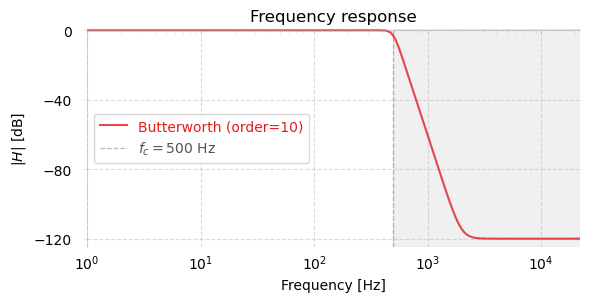

In [3]:
# Fig. 12.3: frequency response for Butterworth filter via scipy.signal.freqz
fig, ax = plt.subplots(figsize=(6, 3))

ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

ax.semilogx(freq, 20 * np.log10(np.abs(H) + 1e-6), label='Butterworth (order=10)', color='#e41a1c', alpha=0.8)
ax.axvline(fc, zorder=-1, label=r'$f_c = 500$ Hz', linewidth=0.9, color='#525252', linestyle='--', alpha=0.4)
ax.axvspan(fc, fs/2, color='#737373', alpha=0.1, zorder=-1)

ax.set(xlabel='Frequency [Hz]', ylabel='$|H|$ [dB]', title='Frequency response');
ax.set(yticks=[0, -40, -80, -120], ylim=[-125., 0.5], xlim=[1., fs/2])#, xticks=[1e-1, fc, fs /2], xlim=[1e-1, fs/2], xticklabels=[0, r'$f_c$', 'Nyquist'])
ax.tick_params(axis='x', which=u'both', length=3, pad=158, color='#A9A9A940')
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')

ax.label_outer()
ax.legend(loc='center left', labelcolor='linecolor')

fig.tight_layout()
plt.show()

#### 12.3.2.2. Example: phase response of an elliptic filter

* You might want to revist the API documentation for [`scipy.signal.ellipord`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.ellipord.html#ellipord) and [`scipy.signal.ellip`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.ellip.html#ellip).

In [4]:
fs = 44100        # Sampling rate
fc = 500          # Cutoff frequency
fstop = 600       # transition band from 500 - 600 Hz
attenuation = 40  # we'll require 40 dB attenuation in the stop band
                  #               ^^^^^^^^^^^^^^^^^
                  # ... funny, the original code comments had that 
                  #     attenuation value at 80 dB...
ripple = 3        # we'll allow 3 dB ripple in the passband

In [5]:
order_ell, wn = sp.signal.ellipord(fc, fstop, ripple, attenuation, fs=fs)
b_ell, a_ell = sp.signal.ellip(order_ell, ripple, attenuation, wn, fs=fs)

##### Analysis: frequency response

To reiterate: The frequency response of a system tells you how different frequency components of an input signal are amplified, attenuated, or left unchanged.

Key aspects of frequency response:
* Roll-off speed – how sharply the filter transitions from pass-band to stop-band.
* Pass-band ripple – how much fluctuation is allowed in the pass-band.
* Stop-band attenuation – how well the filter suppresses unwanted frequencies.

In [6]:
freq_ell, H_ell = sp.signal.freqz(b_ell, a_ell, worN=4096, fs=fs)

##### Analysis: phase response

* Phase response determines how the timing or phase of each frequency component is shifted.
* For systems where time alignment is important (e.g., digital communication, waveform reconstruction), a _linear phase response is essential._
* Linear phase means the signal's shape is preserved: delays are uniform across frequencies.
* Nonlinear phase can cause distortion, especially in time-domain signals like EKG or speech.
* Please refer to [`scipy.signal.group_delay`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.group_delay.html#group-delay)


In [7]:
# scipy's group delay measures in samples
# we'll convert to seconds by dividing out the sampling rate
freq, delay = sp.signal.group_delay([b_ell, a_ell], w=4096, fs=fs)
delay_sec = delay / fs

C:\Users\brooke\AppData\Local\Temp\ipykernel_23220\93366930.py:3: UserWarning: The filter's denominator is extremely small at frequencies [0.071, 0.082, 0.083, 0.084],             around which a singularity may be present
  freq, delay = sp.signal.group_delay([b_ell, a_ell], w=4096, fs=fs)


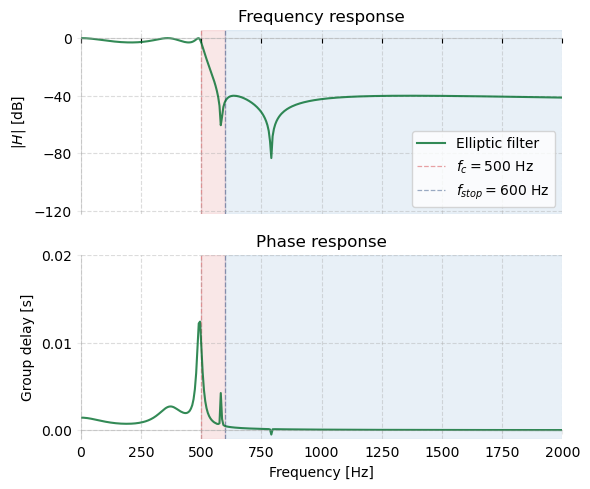

In [8]:
# Frequency response & phase response: Elliptic filter
fig, (ax0, ax1) = plt.subplots(figsize=(6, 5), nrows=2, sharex=True)

# -----------------------------------------------------
# Frequency response
#
ax0.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax0.spines['right'].set_color('none')
ax0.spines['top'].set_color('none')
ax0.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax0.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

# Frequency response
ax0.plot(freq_ell, 20 * np.log10(np.abs(H_ell) + 1e-6), label='Elliptic filter', color='#006d2c', alpha=0.8)
ax0.axvline(fc, zorder=-1, label=r'$f_c = 500$ Hz', linewidth=0.9, color='#cb181d', linestyle='--', alpha=0.4)
ax0.axvline(fstop, zorder=-1, label=r'$f_{stop} = 600$ Hz', linewidth=0.9, color='#08306b', linestyle='--', alpha=0.4)
ax0.axvspan(fc, fstop, zorder=-2, color='#cb181d', alpha=0.1)
ax0.axvspan(fstop, fs/2, zorder=-2, color='#2171b5', alpha=0.1)

ax0.legend(loc='lower right')
ax0.set(xlabel='Frequency [Hz]', ylabel='$|H|$ [dB]', title='Frequency response');
ax0.set(yticks=[0, -40, -80, -120])
#ax.tick_params(axis='x', which=u'both', length=3, pad=158, color='#A9A9A940')
ax0.tick_params(axis='y', which=u'both', length=3, color='#A9A9A940')

ax0.label_outer()

# -----------------------------------------------------
# Phase response: unwrapped group delay
#
ax1.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax1.spines['right'].set_color('none')
ax1.spines['top'].set_color('none')
ax1.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax1.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

ax1.plot(freq, delay_sec, label='Elliptic filter', color='#006d2c', alpha=0.8)
ax1.axvline(fc, zorder=-1, label=r'$f_c = 500$ Hz', linewidth=0.9, color='#cb181d', linestyle='--', alpha=0.4)
ax1.axvline(fstop, zorder=-1, label=r'$f_{stop} = 600$ Hz', linewidth=0.9, color='#08306b', linestyle='--', alpha=0.4)
ax1.axvspan(fc, fstop, zorder=-2, color='#cb181d', alpha=0.1)
ax1.axvspan(fstop, fs/2, zorder=-2, color='#2171b5', alpha=0.1)

ax1.set(xlabel='Frequency [Hz]', ylabel='Group delay [s]', title='Phase response');
ax1.set(xlim=[0, 2000], ylim=[-0.001, 0.02])
ax1.set(yticks=[0., 0.01, 0.02])
ax1.tick_params(axis='y', which=u'both', length=3, color='#A9A9A940')
ax1.tick_params(axis='x', which=u'both', length=3, pad=8, color='#A9A9A940')
ax1.label_outer()

fig.tight_layout()
plt.show()

### 12.3.3. Why not use the DTFT?

##### _From a recent session with ChatGPT 4o in my DSP project..._

> OK, so what is the difference between the z-transform and the DTFT? please give examples where i should choose one over the other.

ChatGPT responded with the following table:

<div style="display: inline-block">

| Feature           | **DTFT**                                      | **Z-transform**                                |
| ----------------- | --------------------------------------------- | ---------------------------------------------- |
| **Definition**    | $X(e^{j\omega}) = \sum x[n] e^{-j\omega n}$   | $X(z) = \sum x[n] z^{-n}$                      |
| **Domain**        | <span style="background-color:rgba(233,163,201,0.3)">Frequency domain (unit circle in the z-plane)</span> | <span style="background-color:rgba(161,215,106,0.3)">Z-domain (entire complex plane)</span>                |
| **Variable**      | $\omega$ (real-valued frequency)              | $z = re^{j\omega}$ (complex variable)          |
| **Used for**      | Frequency response, spectral analysis         | System analysis, filter design, stability      |
| **Convergence**   | Requires absolute summability                 | Has a region of convergence (ROC)              |
| **Output**        | Periodic, continuous function over ω          | Complex function with poles/zeros              |
| **Invertibility** | Yes, via inverse DTFT                         | Yes, via contour integral or partial fractions |

</div>

... so, in the IIR analysis technique coming up, we would actually like to be working in the **_entire_** $\mathbb{Z}$-domain and not just on the unit-circle in the $\mathbb{Z}$-plane.

Using the _z-transform_ allows us to reason about the _stability_ of a filter, and this is done in the complex $\mathbb{Z}$-domain.

## 12.4. Stability, poles, and zeros

Here's an example of an _unstable_ system:

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#377eb8}x[n]} + 2 \cdot {\color{#984ea3}y[n-1]} &  \\\\
\end{flalign}

If we input a unit impulse ${\color{#377eb8}x[n] = [1,0,0,0,\ldots]}$ into the above system, we see why it is _unstable_:

\begin{flalign}
\qquad {\color{#984ea3}y[0]} &= {\color{#377eb8}x[0]} + 2 \cdot {\color{#984ea3}0} = 1  & \\
\qquad {\color{#984ea3}y[1]} &= {\color{#377eb8}x[1]} + 2 \cdot {\color{#984ea3}y[0]} = 2  & \\
\qquad {\color{#984ea3}y[2]} &= {\color{#377eb8}x[2]} + 2 \cdot {\color{#984ea3}y[1]} = 4  \\
\qquad     & \ldots & \\
\qquad {\color{#984ea3}y[n]} &= 2^{n} & \\
\end{flalign}

_How can we determine stability in a general, consistent manner?_

### 12.4.1. Transfer functions and polynomials

Recall the _transfer function_ definition:

\begin{flalign}
\qquad H(z) &= \frac{{\color{#e41a1c}B(z)}}{{\color{#4daf4a}A(z)}} = \frac{ \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot z^{-k} }{ \sum_{k=0}^{K-1} {\color{#4daf4a}a[k]} \cdot z^{-k} } & \\
\end{flalign}

$H(z)$ can be seen as the results of _dividing_ two polynomials ${\color{#e41a1c}B(z)}$ and ${\color{#4daf4a}A(z)}$:

\begin{flalign}
\qquad {\color{#e41a1c}B(z)} &= {\color{#e41a1c}b[0]} \cdot z^0 + {\color{#e41a1c}b[1]} \cdot z^{-1} + {\color{#e41a1c}b[2]} \cdot z^{-2} + \cdots +  {\color{#e41a1c}b[K-1]} \cdot z^{-(K-1)} & \\
\qquad {\color{#4daf4a}A(z)} &= {\color{#4daf4a}a[0]} \cdot z^0 + {\color{#4daf4a}a[1]} \cdot z^{-1} + {\color{#4daf4a}a[2]} \cdot z^{-2} + \cdots +  {\color{#4daf4a}a[K-1]} \cdot z^{-(K-1)} & \\
\end{flalign}

We can reason about filter's behavior by examining the properties of these polynomials, and specifically, finding their roots by solving ${\color{#e41a1c}B(z) = 0}$ and ${\color{#4daf4a}A(z) = 0} $.

#### 12.4.1.1. Roots and algebra

From the Fundamental Theorem of Algebra, we know:

* Any polynomial of degree $D \geq 1$ has exactly $D$ roots (counted with _multiplicity_).
* These roots do not need to be unique (the _multiplicity_ bit).
* These roots may be complex-valued.

### 12.4.2. Zeros

To gain some intuition, let's focus in on numerator ${\color{#e41a1c}B(z)}$.

* If $z_0$ is a root of ${\color{#e41a1c}B(z)}$, then ${\color{#e41a1c}B(z_0) = 0}$ by definition.
* As long as $z_0$ is not also a root of ${\color{#4daf4a}A(z)}$, we will have:

\begin{flalign}
\qquad H(z_0) &= \frac{{\color{#e41a1c}B(z_0)}}{{\color{#4daf4a}A(z_0)}} = \frac{{\color{#e41a1c}0}}{{\color{#4daf4a}A(z_o)}} = 0 & \\
\end{flalign}

* Because polynomials are continuous, if ${\color{#e41a1c}B(z_0) = 0}$ then other values of $z$ near $z_0$ will be small (${\color{#e41a1c}B(z) \approx 0}$).

In [9]:
# parameters for the Chebyshev Type-2 filter in this section
fs = 8000         # Sampling rate
fc = 1000         # Cutoff frequency
fstop = 1500
attenuation = 80  # we'll require 80 dB attenuation in the stop band
                  #               ^^^^^^^^^^^^^^^^^
ripple = 6        # we'll allow 6 dB ripple in the passband

##### _NOTE: `output='zpk'` argument in `scipy.signal` APIs for IIR filters_

N.B., in [the accompanying code for this section](https://github.com/bmcfee/dstbook/blob/main/content/ch12-ztransform/PoleZero.ipynb), the author does _not_ use [`scipy.signal.tf2zpk`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.tf2zpk.html#tf2zpk) to obtain the zeros... instead, the `output='zpk'` argument to [`scipy.signal.cheby2`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.cheby2.html#cheby2) is used to obtain the zeros, poles, and system gain of the IIR filter transfer function.

Support for the `output='zpk'` argument is available in [`scipy.signal.butter`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.butter.html#scipy.signal.butter), [`scipy.signal.cheby1`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.cheby1.html#cheby1), [`scipy.signal.cheby2`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.cheby2.html#cheby2), and [`scipy.signal.ellip`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.ellip.html#scipy.signal.ellip), which we've seen so far.

#### On ZPK form

I had to ask ChatGPT 4o about this "ZPK form"...


\begin{flalign}
\qquad H(z) &= k \cdot \frac{(z - z_0)(z - z_1)(z - z_2)  \cdots (z - z_{K-1})}{(z - p_0)(z - p_1)(z - p_2) \cdots (z - p_{K-1})} & \\
\end{flalign}

where

* $z_1, z_2, \ldots , z_M$ are the **zeros** (roots of the numerator)
* $p_1, p_2, \ldots , p_N$ are the **poles** (roots of the denominator)
* $k$ is the **gain** in the system (constant scaling factor)

In particular when reasoning about an IIR system, **_stability analysis_** looks for the poles to be _inside_ the unit circle as evidence the system is causal and stable.

BTW, the text uses the **_coefficient form_**, or the _Transfer Function._

In [10]:
order_ell, wn = sp.signal.cheb2ord(fc, fstop, ripple, attenuation, fs=fs)

zeros, poles, gain = sp.signal.cheby2(order_ell, attenuation, wn, fs=fs, output='zpk')

print(zeros)

[ 0.38141995-0.92440187j  0.26658886-0.96381034j -0.02490664-0.99968978j
 -0.57559933-0.81773187j -0.57559933+0.81773187j -0.02490664+0.99968978j
  0.26658886+0.96381034j  0.38141995+0.92440187j -1.        +0.j        ]


##### _NOTE: Frequency response in ZPK form..._

[`scipy.signal.freqz_zpk`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.freqz_zpk.html#freqz-zpk) is used to compute the frequency response of a filter in ZPK form. 

In [11]:
# for analyzing the frequency response
freq, H = sp.signal.freqz_zpk(zeros, poles, gain, fs=fs)

### 12.4.2. Zeros, con't

Continuing on, we can take the _zeros_ output we just obtained from the call to `cheby2`, and plot these in the _complex plane._ We can then compare them to the frequency response which we just obtained via `freqz_zpk` above.

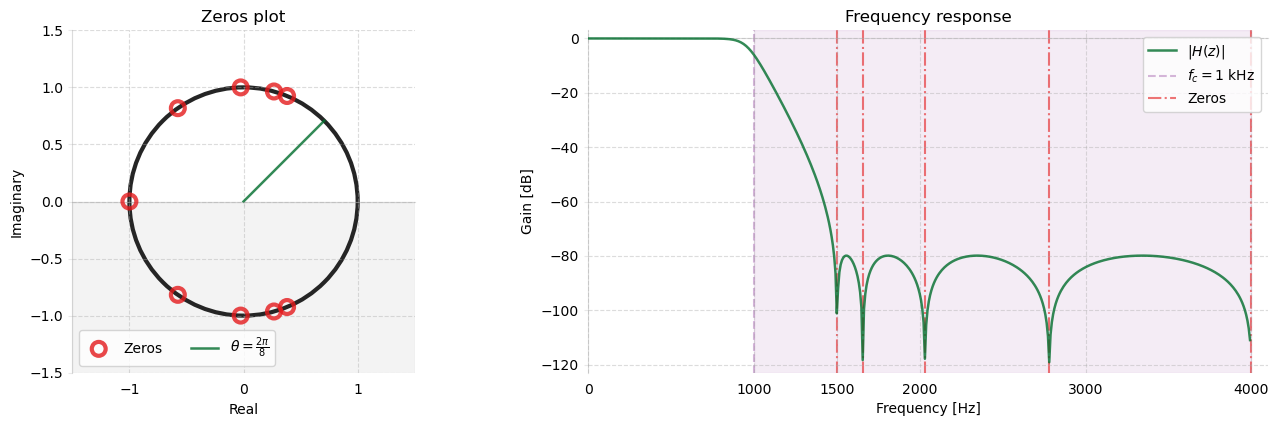

In [12]:
fig, (ax, ax1) = plt.subplots(figsize=(14, 4.4), ncols=2)

# -----------------------------------------------------
# Zeros plot
#
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

circ = patches.Ellipse((0, 0), 2, 2, edgecolor='#252525', linewidth=3, fill=False, zorder=-10)
ax.add_patch(circ)

ax.scatter(zeros.real, zeros.imag, marker='o', s=100, edgecolor='#e41a1c', color=None, facecolor='none', linewidth=3, label='Zeros', alpha=0.8, zorder=10)
ax.plot([0, np.cos(2 * np.pi / 8)], [0, np.sin(2 * np.pi / 8)], label=r'$\theta = \frac{2\pi}{8}$', linewidth=1.8, color='#006d2c', alpha=0.8)
ax.axhspan(-1.6, 0, alpha=0.05, color='#252525', zorder=-1)

ax.set(xlim=[-1.5, 1.5], ylim=[-1.5, 1.5], aspect='equal', xlabel='Real', ylabel='Imaginary')
ax.set(xticks=[-1, 0, 1])
ax.tick_params(axis='y', which=u'both', length=3, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=128, color='#A9A9A940')
ax.legend(loc='lower left', ncol=2)
ax.set(title='Zeros plot')

# -----------------------------------------------------
# Frequency response
#
ax1.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax1.spines['right'].set_color('none')
ax1.spines['top'].set_color('none')
ax1.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax1.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

ax1.plot(freq, 20 * np.log10(np.abs(H) + 1e-6), label='$|H(z)|$', linewidth=1.8, color='#006d2c', alpha=0.8, zorder=10)

ax1.axvline(fc, zorder=-1, label=r'$f_c = 1$ kHz', color='#984ea3', linestyle='--', alpha=0.4)
ax1.axvspan(fc, fs/2, zorder=-2, color='#984ea3', alpha=0.1)

ax1.vlines(np.angle(zeros) * fs / (2 * np.pi), -140, 10, linestyle='-.', label='Zeros', color='#e41a1c', alpha=0.6, zorder=1)

ax1.set(xlim=[0, fs/2 + 100], ylim=[-123, 3])
ax1.tick_params(axis='y', which=u'both', length=3, color='#A9A9A940')
ax1.tick_params(axis='x', which=u'both', length=3, pad=245, color='#A9A9A940')
ax1.set(xticks=[0, 1000, 1500, 2000, 3000, 4000])
ax1.set(xlabel='Frequency [Hz]', ylabel='Gain [dB]')
ax1.set(title='Frequency response')
ax1.legend(loc='upper right')

fig.tight_layout()
plt.show()

##### Interpreting the Zeros and Frequency response plots

Again, here are the parameters for the Chebyshev Type-2 system in question:

* sampling rate $f_s = 8 \text{ kHz}$
* cut-off frequency $f_c = 1 \text{ kHz}$
* transition-band edge at $f_{stop} = 1.5 \text{ kHz}$
* desired stop-band attenuation of $80 \text{ dB}$
* desired pass-band ripple of $6 \text{ dB}$

##### From the `zeros` returned from `cheby2`, we know that there are 9 zeros in our filter, and they are _conjugate pairs._

* 4 have a _positive_ imaginary component
* 4 have a corresponding _negative_ imaginary component
* 1 has a zero imaginary component, and that is at _Nyquist frequency_
* Notice how all of this information is easily understood from the Pole-zero graph

In [13]:
# just for laughs, let's just see (in degrees) where those zeros are...
for zer in zeros:
    print(np.angle(zer, deg=True))

-67.57833429922432
-74.53861528638326
-91.42719276779991
-125.14161459972465
125.14161459972465
91.42719276779991
74.53861528638326
67.57833429922432
180.0


##### From the _minima_ in the Frequency response 

* Notice how the _minima_ in the frequency response graph correspond to the zeros in our transfer function.
* Note also how the frequencies in the immediate neighborhood of these minima are also _attenuated_.

### 12.4.3. Poles

We've examined ${\color{#e41a1c}B(z)}$ in the numerator of the transfer function and the zeros in the ZPK form. Let's now turn our attention to the _denominator_ and ${\color{#4daf4a}A(z)}$.

##### Intuition

* Any root of ${\color{#4daf4a}A(z)}$ that is **not** also a root of ${\color{#e41a1c}B(z)}$ will result in _division by zero_.
* From this asymptotic behavior of the **_poles_**, we can intuit that these locations are where the filter will **_amplify_** frequencies.

In [14]:
print(poles)

[0.6640386 -0.61973512j 0.54573487-0.49475044j 0.44310112-0.35506889j
 0.36783278-0.18847207j 0.3394446 +0.j         0.36783278+0.18847207j
 0.44310112+0.35506889j 0.54573487+0.49475044j 0.6640386 +0.61973512j]


#### Pole-zero plot (and frequency response)

A **_pole-zero plot_** visualizes both the zeros and the poles in complex plan, and this allows us to more fully reason about the behavior of an IIR filter.

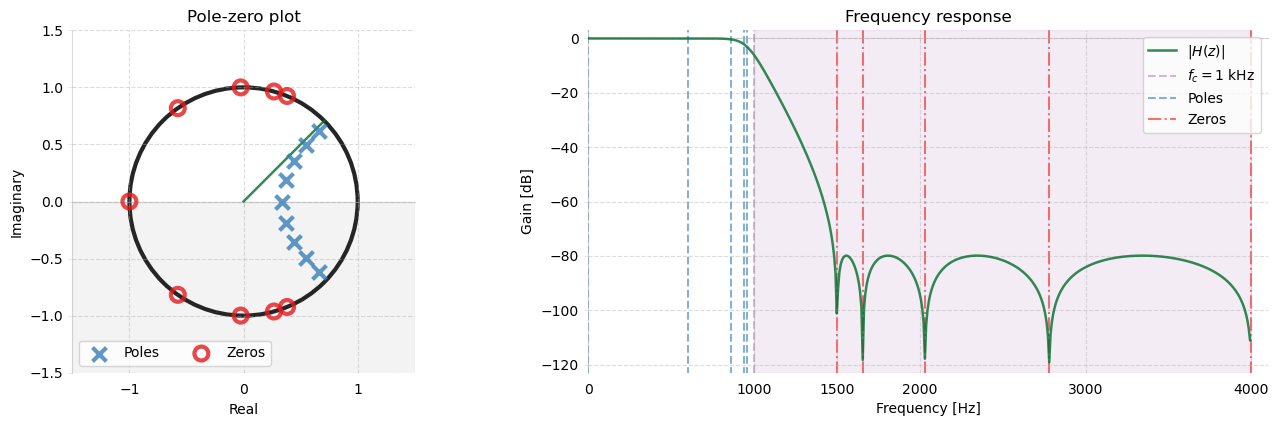

In [15]:
fig, (ax, ax1) = plt.subplots(figsize=(14, 4.4), ncols=2)

# -----------------------------------------------------
# Poles-eros plot
#
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

circ = patches.Ellipse((0, 0), 2, 2, edgecolor='#252525', linewidth=3, fill=False, zorder=-10)
ax.add_patch(circ)

ax.scatter(poles.real, poles.imag, marker='x', s=100, linewidth=3, label='Poles', color='#377eb8', alpha=0.8, zorder=10)
ax.scatter(zeros.real, zeros.imag, marker='o', s=100, edgecolor='#e41a1c', color=None, facecolor='none', linewidth=3, label='Zeros', alpha=0.8, zorder=10)
ax.plot([0, np.cos(2 * np.pi / 8)], [0, np.sin(2 * np.pi / 8)], linewidth=1.8, color='#006d2c', alpha=0.8)
ax.axhspan(-1.6, 0, alpha=0.05, color='#252525', zorder=-1)

ax.set(xlim=[-1.5, 1.5], ylim=[-1.5, 1.5], aspect='equal', xlabel='Real', ylabel='Imaginary')
ax.set(xticks=[-1, 0, 1])
ax.tick_params(axis='y', which=u'both', length=3, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=128, color='#A9A9A940')
ax.legend(loc='lower left', ncol=2)
ax.set(title='Pole-zero plot')

# -----------------------------------------------------
# Frequency response
#
ax1.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax1.spines['right'].set_color('none')
ax1.spines['top'].set_color('none')
ax1.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax1.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

ax1.plot(freq, 20 * np.log10(np.abs(H) + 1e-6), label='$|H(z)|$', linewidth=1.8, color='#006d2c', alpha=0.8, zorder=10)

ax1.axvline(fc, zorder=-1, label=r'$f_c = 1$ kHz', color='#984ea3', linestyle='--', alpha=0.4)
ax1.axvspan(fc, fs/2, zorder=-2, color='#984ea3', alpha=0.1)
ax1.vlines(np.angle(poles) * fs / (2 * np.pi), -140, 10, linestyle='--', label='Poles', color='#377eb8', alpha=0.6, zorder=1)
ax1.vlines(np.angle(zeros) * fs / (2 * np.pi), -140, 10, linestyle='-.', label='Zeros', color='#e41a1c', alpha=0.6, zorder=1)

ax1.set(xlim=[0, fs/2 + 100], ylim=[-123, 3])
ax1.tick_params(axis='y', which=u'both', length=3, color='#A9A9A940')
ax1.tick_params(axis='x', which=u'both', length=3, pad=245, color='#A9A9A940')
ax1.set(xticks=[0, 1000, 1500, 2000, 3000, 4000])
ax1.set(xlabel='Frequency [Hz]', ylabel='Gain [dB]')
ax1.set(title='Frequency response')
ax1.legend(loc='upper right')

fig.tight_layout()
plt.show()

##### Interpreting the Pole-zero and Frequency response plots

Some observations now that we have both zeros and poles in our graphs.

* we appear to have zeros at high frequencies (angles approaching $\pi$)
* zeros landing exactly on the unit circle tells us that some frequencies will be attenuated severely (practically to zero)
* we appear to have poles (asymptotic behavior) near lower frequencies
* ... so we can infer that this is a _low-pass filter_
* a high-pass filter would exhibit the reverse behavior, with poles at larger angles and zeros at smaller angles

### 12.4.4. Factored transfer functions

With the zeros $z_k$ and poles $p_k$ of a system, we can re-write transfer function $H(z)$ equivalently into its _factored form._ Note the similarity with the aforementioned **_ZPK_** form.

\begin{flalign}
\qquad H(z) &= \frac{(z - z_0)(z - z_1)(z - z_2)  \cdots (z - z_{K-1})}{(z - p_0)(z - p_1)(z - p_2) \cdots (z - p_{K-1})} & \\\\
\qquad      &= \left( \frac{z - z_0}{z - p_0} \right) \cdot \left( \frac{z - z_1}{z - p_1} \right) \cdot \left( \frac{z - z_2}{z - p_2} \right) \cdots \left( \frac{z - z_{K-1}}{z - p_{K-1}} \right) & \\\\
\qquad      &= H_0(z) \cdot H_1(z) \cdot H_2(z) \cdots H_{K-1}(z) & \\\\
\end{flalign}

This, in turn, allows us to simplify the IIR filter implementation and improve stability, _without changing the filter's behavior_ (fine-tuning?).

#### _second-order sections_ method

The _factored form_ of the transfer function provides a way to reason about the interactions between poles and zeros. Notably, if we have a pole which is also a zero, that is, $p_k = z_t$, then both of their corresponding factors can be removed from the filter without changing its behavior. Concretely, this means that if a pole and a zero coincide, then their effects cancel each other out.

Have a look at the `output='sos'` argument to [`scipy.signal.cheby2`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cheby2.html#scipy.signal.cheby2). Again, this `output='sos'` argument is available all of the IIR filter implementations in this chapter.

### 12.4.5. Stability

> #### IIR stability
> Let $H(z)$ denote the transfer function of a linear IIR filter with zeros ${\color{#e41a1c}z_0, z_1, z_2, \ldots, z_{K-1}}$
> and poles ${\color{#377eb8}p_0, p_1, p_2, \ldots, p_{K-1}}$; and assume that no pole is also a zero.
> <p/>
> The filter is <b>stable</b> if <b>all</b> poles ${\color{#377eb8}p}$ have magnitude $|{\color{#377eb8}p}| \lt 1$.
> Or, equivalently, if all poles lie within the unit circle in the complex plane.
> <p/>
> The filter is <b>unstable</b> if <b>any</b> pole ${\color{#377eb8}p}$ has magnitude $|{\color{#377eb8}p}| \gt 1$.

#### Example: $y[n] = x[n] + 2 \cdot y[n-1]$

Recall the earlier example of the simple and **unstable** IIR filter.

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#377eb8}x[n]} + 2 \cdot {\color{#984ea3}y[n-1]} &  \\\\
\end{flalign}

The _coefficients_ are:

\begin{flalign}
\qquad {\color{#e41a1c}b} &= [1] &  \\
\qquad {\color{#4daf4a}a} &= [1, -2] &  \\\\
\end{flalign}

The _transfer function_ is:

\begin{flalign}
\qquad {\color{#e41a1c}H(z_0)} &= \frac{{\color{#e41a1c}b[0]} \cdot z^0}{{\color{#4daf4a}a[0]} \cdot z^0 + {\color{#4daf4a}a[1]} \cdot z^{-1}} & \\\\
\qquad                         &= \frac{{\color{#e41a1c}1} \cdot 1}{{\color{#4daf4a}1} \cdot 1 + {\color{#4daf4a}-2} \cdot z^{-1}} & \\\\
\qquad                         &= \frac{{\color{#e41a1c}1}}{{\color{#4daf4a}1} - {\color{#4daf4a}2} \cdot z^{-1}} & \\\\
\end{flalign}

Analyzing this polynomial, we have:
* the _numerator_ has degree 0 so this system has no zeros
* it has _one pole_, which we can find by solving $1 - 2 \cdot z^{-1} = 0$

\begin{flalign}
\qquad {\color{#4daf4a}1} - {\color{#4daf4a}2} \cdot z^{-1} &= 0 \Rightarrow \frac{2}{{\color{#377eb8}z}} = 1 \Rightarrow {\color{#377eb8}z} = 2 & \\\\
\end{flalign}

* as the only pole of this system $|{\color{#377eb8}p}| \gt 1$, we know that this system is **_unstable_**.

#### Example: exponential moving average $y[n] = \frac{1}{2} \cdot x[n] + \frac{1}{2} \cdot y[n-1]$

Recall the _exponential moving average_ (11.1)

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= \frac{1}{2} \cdot {\color{#377eb8}x[n]} + \frac{1}{2} \cdot {\color{#984ea3}y[n-1]} &  \\\\
\end{flalign}

The _coefficients_ are:

\begin{flalign}
\qquad {\color{#e41a1c}b} &= \left[ \frac{1}{2} \right] &  \\
\qquad {\color{#4daf4a}a} &= \left[ 1, -\frac{1}{2} \right] &  \\\\
\end{flalign}

The _transfer function_ is:

\begin{flalign}
\qquad {\color{#e41a1c}H(z_0)} &= \frac{{\color{#e41a1c}b[0]} \cdot z^0}{{\color{#4daf4a}a[0]} \cdot z^0 + {\color{#4daf4a}a[1]} \cdot z^{-1}} & \\\\
\qquad                         &= \frac{{\color{#e41a1c}\frac{1}{2}} \cdot 1}{{\color{#4daf4a}1} \cdot 1 + {\color{#4daf4a}-2} \cdot z^{-1}} & \\\\
\qquad                         &= \frac{{\color{#e41a1c}1}}{{\color{#4daf4a}1} + {\color{#4daf4a}-\frac{1}{2}} \cdot z^{-1}} & \\\\
\qquad                         &= \frac{{\color{#e41a1c}1}}{{\color{#4daf4a}1} - {\color{#4daf4a}\frac{1}{2}} \cdot z^{-1}} & \\\\
\end{flalign}

Analyzing this polynomial, we have:
* the _numerator_ has degree 0 so this system has no zeros
* it has _one pole_, which we can find by solving $1 - \frac{1}{2} \cdot z^{-1} = 0$

\begin{flalign}
\qquad {\color{#4daf4a}1} - {\color{#4daf4a}\frac{1}{2}} \cdot z^{-1} &= 0 \Rightarrow \frac{1}{2 \cdot {\color{#377eb8}z}} = 1 \Rightarrow {\color{#377eb8}z} = \frac{1}{2} & \\\\
\end{flalign}

* in contrast to the above example of an unstable filter, as the only pole of this system $|{\color{#377eb8}p}| \lt 1$, we see that this system is **_stable_**.

#### Criteria for simple stability test

1. Compute the poles of the filter, e.g., by [`scipy.signal.tf2zpk`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.tf2zpk.html#tf2zpk) or [`scipy.signal.sos2zpk`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.sos2zpk.html#sos2zpk).
1. Discard any poles which are also zeros.
1. Compute the magnitude of all remaining poles.
1. If any pole has magnitude larger than 1, the filter is unstable.

##### Corollary

* As a corollary to this observation, note that FIR filters have no poles (since ${\color{#377eb8}A(z) = a[0] = 1 \neq 0}$
).
* Since they have no poles, they also have no poles with magnitude larger than 1.
* This is how we can say that **_any FIR filter is stable_**.

----

## 12.5. Exercises

#### Exercise 12.1

Compute the poles and zeros for the following filters. Provide a brief analysis of stability.

1. $y[n] = \frac{1}{2} \cdot x[n] + \frac{1}{2} \cdot y[n-1] - y[n-2]$

The _coefficients_ are:

\begin{flalign}
\qquad {\color{#e41a1c}b} &= \left[ \frac{1}{2} \right] &  \\
\qquad {\color{#4daf4a}a} &= \left[ 1, -\frac{1}{2}, 1 \right] &  \\\\
\end{flalign}

The _transfer function_ is:

\begin{flalign}
\qquad {\color{#e41a1c}H(z_0)} &= \frac{{\color{#e41a1c}b[0]} \cdot z^0}{{\color{#4daf4a}a[0]} \cdot z^0 + {\color{#4daf4a}a[1]} \cdot z^{-1} + {\color{#4daf4a}a[2]} \cdot z^{-2}} & \\\\
\qquad   &= \frac{{\color{#e41a1c}\frac{1}{2}} \cdot 1}{{\color{#4daf4a}1} \cdot 1 + {\color{#4daf4a}-\frac{1}{2}} \cdot z^{-1} + {\color{#4daf4a}1} \cdot z^{-2}} & \\\\
\qquad   &= \frac{{\color{#e41a1c}\frac{1}{2}}}{{\color{#4daf4a}1} - {\color{#4daf4a}\frac{1}{2}} \cdot z^{-1} + z^{-2}} & \\\\
\end{flalign}

Looking at the _numerator_, there are no zeros as it has degree 0.

Looking at the _denominator_, we need to solve $1 - \frac{1}{2 \cdot z} + \frac{1}{z^2} = 0$ to get the roots (which are the poles).

Multiplying through by $z^2$, we have $z^2 - \frac{1}{2} \cdot z + 1 = 0$

Applying the _quadratic formula_, we have:

\begin{flalign}
\qquad z &= \frac{-(-\frac{1}{2}) \pm \sqrt{(- \frac{1}{2})^2 - (4 \cdot 1 \cdot 1)}}{2 \cdot 1} & \\\\
\qquad   &= \frac{\frac{1}{2} \pm \sqrt{\frac{1}{4} - 4}}{2}  & \\\\
\qquad   &= \frac{\frac{1}{2} \pm j \cdot \sqrt{\frac{15}{4}}}{2}  & \\\\
\qquad   &= \frac{1}{4} \pm j \cdot \frac{\sqrt{\frac{15}{4}}}{2}  & \\\\
\end{flalign}

Now let's check the _magnitude_ for these 2 poles.

In [16]:
p = complex(0.25, np.sqrt(15/4) / 2)
print(p, np.abs(p))

(0.25+0.9682458365518543j) 0.9999999999999999


In [17]:
p = complex(0.25, -np.sqrt(15/4) / 2)
print(p, np.abs(p))

(0.25-0.9682458365518543j) 0.9999999999999999


##### Answer

* As the _numerator_ of ${\color{#e41a1c}H(z_0)}$ has no zeros, this system has no zeros.
* There are two poles ${\color{#377eb8}p = \frac{1}{4} \pm j \cdot \frac{\sqrt{\frac{15}{4}}}{2} }$
* Since both of these poles ${\color{#377eb8}p} \leq 1$, this system is **_stable_**

<hr width=40%/>

2. $y[n] = x[n] + x[n-2] - 2 \cdot y[n-1]$

#### Exercise 12.2

#### Exercise 12.3